These distribution plots are after redundant sequences have been removed. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## CDRH3 Length Distribution

In [44]:
def get_cdrh3_lengths(search_name):
    '''
    Load in sequences, calculate cdrh3 lengths. 
    '''
    load_path=f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/PG9/{search_name}/data/parsed_logfile/' # path to where the search results are (logfile).  
    cdrh3_sequences_per_donor = np.load(f'{load_path}redundant_seqs_removed_within_donors_cdrh3_final.npy', allow_pickle=True) # load in the data after redudant sequences per donor have been removed. 
    cdrh3_lengths_donors_combined = [] # number of non-redundant sequences per donor. 'collapsed' = non-redundant. 
    for i in range(len(cdrh3_sequences_per_donor)): # iterate through all donors. 
        for j in range(len(cdrh3_sequences_per_donor[i])):
            cdrh3_lengths_donors_combined.append(int(len(cdrh3_sequences_per_donor[i][j]))) # save the number of sequences. 
    return cdrh3_lengths_donors_combined

In [45]:
search_name = 'search7'
cdrh3_lengths_donors_combined = get_cdrh3_lengths(search_name)
print('Number of sequences \t', len(cdrh3_lengths_donors_combined))
print('Shortest CDRH3\t\t', np.min(cdrh3_lengths_donors_combined))
print('Longest CDRH3\t\t', np.max(cdrh3_lengths_donors_combined))

Number of sequences 	 38427
Shortest CDRH3		 22
Longest CDRH3		 38


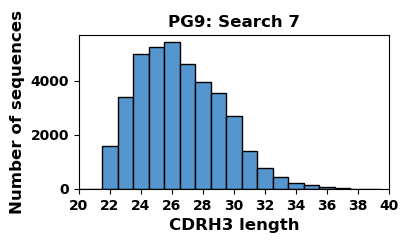

In [52]:
lengths = cdrh3_lengths_donors_combined

barplot_lengths = []
for i in range(20,40):
    barplot_lengths.append(lengths.count(i))
plt.figure(figsize=[4,2])
plt.bar(np.arange(20,40), barplot_lengths, width=1, edgecolor='k', color='#5596ce')
plt.xticks(np.arange(20,42,2))
plt.xlim(20,40)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Number of sequences',weight='bold', fontsize=12)
plt.xlabel('CDRH3 length',weight='bold', fontsize=12)
plt.title('PG9: Search 7',weight='bold', fontsize=12)

figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_CDRH3_length_distribution.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_CDRH3_length_distribution.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## gene distribution

In [5]:
def group_according_to_donors(updated_donor_names, updated_vgene, updated_dgene, updated_jgene, save_path):
    import numpy as np
    
    dgenes = updated_dgene
    jgenes = updated_jgene
    vgenes = updated_vgene
    
    donor_names = updated_donor_names
    unique_donor_names = np.unique(updated_donor_names)

    vgenes_by_donor = []
    dgenes_by_donor = []
    jgenes_by_donor = []
    for i in range(len(unique_donor_names)):
        tmp_vgene = []
        tmp_dgene = []
        tmp_jgene = []
        for j in range(len(donor_names)):
            tmp_tmp_vgene = []
            tmp_tmp_dgene = []
            tmp_tmp_jgene = []
            if donor_names[j] == unique_donor_names[i] and donor_names[j] != 'no' and donor_names[j] != 'no_donor_name_found':
                tmp_tmp_vgene.append(vgenes[j])
                tmp_tmp_dgene.append(dgenes[j])
                tmp_tmp_jgene.append(jgenes[j])
            tmp_vgene.append(tmp_tmp_vgene)
            tmp_dgene.append(tmp_tmp_dgene)
            tmp_jgene.append(tmp_tmp_jgene)
        vgenes_by_donor.append(np.concatenate(tmp_vgene))
        dgenes_by_donor.append(np.concatenate(tmp_dgene))
        jgenes_by_donor.append(np.concatenate(tmp_jgene))

    np.save(f'{save_path}vgenes_by_donor',np.array(vgenes_by_donor, dtype=object))
    np.save(f'{save_path}dgenes_by_donor',np.array(dgenes_by_donor, dtype=object))
    np.save(f'{save_path}jgenes_by_donor',np.array(jgenes_by_donor, dtype=object))

    return unique_donor_names, vgenes_by_donor, dgenes_by_donor, jgenes_by_donor

In [6]:
def generate_unique_seqs(cdrh3_seqs_by_donor, genes_by_donor, save_path):
    import numpy as np
    unique_cdrh3_seqs_by_donor_ind = []
    unique_cdrh3_seqs_by_donor = []
    for i in range(len(cdrh3_seqs_by_donor)):
        unique_cdrh3_seqs_by_donor.append(np.unique(cdrh3_seqs_by_donor[i], return_index=True)[0])
        unique_cdrh3_seqs_by_donor_ind.append(np.unique(cdrh3_seqs_by_donor[i], return_index=True))

    unique_genes_by_donor = []
    for i in range(len(genes_by_donor)):
        unique_genes_by_donor_temp = []
        for j in range(len(unique_cdrh3_seqs_by_donor_ind[i][1])):            
            n = unique_cdrh3_seqs_by_donor_ind[i][1][j]
            unique_genes_by_donor_temp.append(genes_by_donor[i][n])
        unique_genes_by_donor.append(unique_genes_by_donor_temp)

    return unique_cdrh3_seqs_by_donor, unique_genes_by_donor

def diff_letters(a,b): 
    '''reports the number of different letters (residues)'''
    return sum ( a[i] != b[i] for i in range(len(a)) )
    
def remove_almost_duplicates(unique_cdrh3_seqs_by_donor, unique_genes_by_donor, save_path):
    '''
    data = unique_cdrh3_seqs_by_donor[0]
    '''
    import numpy as np
    dataset = unique_cdrh3_seqs_by_donor
    dataset_gene = unique_genes_by_donor

    different_seqs_final      = [] # final cdrh3 sequences
    different_seqs_final_gene = [] # final vgenes

    # get unique cdrh3 lengths:
    unique_lengths = []
    for seq in range(len(dataset)):
        unique_lengths.append(len(dataset[seq]))
    unique_lengths = np.unique(unique_lengths)

    # group data into unique length groups:
    unique_length_groups = []
    unique_length_groups_gene = []
    for length in range(len(unique_lengths)):
        unique_length_groups_0 = [] # full
        unique_length_groups_0_gene = []
        for seq in range(len(dataset)):
            unique_length_groups_00 = []
            unique_length_groups_00_gene = []
            if len(dataset[seq]) == unique_lengths[length]:
                unique_length_groups_00.append(dataset[seq])
                unique_length_groups_00_gene.append(dataset_gene[seq])
            #print(len(unique_length_groups_00), len(unique_length_groups_00_gene))
            unique_length_groups_0.append(unique_length_groups_00)
            unique_length_groups_0_gene.append(unique_length_groups_00_gene)
        #print(len(unique_length_groups_0), unique_length_groups_0[0]) # per donor
        unique_length_groups.append(np.concatenate(unique_length_groups_0))
        unique_length_groups_gene.append(np.concatenate(unique_length_groups_0_gene))

   # print(len(unique_length_groups), unique_length_groups[0])
    # for each unique length group, get rid of duplicates and almost duplicates
    for group in range(len(unique_length_groups)):
        if len(unique_length_groups[group]) == 1: # if there's only 1 sequence, then save that sequence
            #print(len(unique_length_groups[group]), unique_length_groups[group][0])
            different_seqs_final.append(unique_length_groups[group][0])
            different_seqs_final_gene.append(unique_length_groups_gene[group][0])

        all_seqs_updated = []
        all_seqs_updated_gene = [] # new line # all_seqs_full


        if len(unique_length_groups[group]) > 1: # if more than 1 sequence,
            #print(len(unique_length_groups), len(unique_length_groups_gene))
            all_seqs = unique_length_groups[group]
            all_seqs_gene = unique_length_groups_gene[group] #unique_length_groups[group] # new line

            a = unique_length_groups[group]
            b = unique_length_groups[group]
            pairs = [(i, j) for i in a for j in b if i < j] # make pairwise pairs of the sequences
            #print('number of pairs:', len(pairs))
# all_seqs_full
#all_seqs_updated
            for pair in range(len(pairs)):
                n_diff = diff_letters(pairs[pair][0], pairs[pair][1])
                if n_diff <= (int(len(pairs[pair][0])*0.15)):                 # 15% / 85%
                    #print(n_diff, pairs[pair][0], pairs[pair][1])
                    result = np.where(all_seqs==f'{pairs[pair][1]}')[0]
                    all_seqs = np.delete(all_seqs, result)
                    all_seqs_gene =  np.delete(all_seqs_gene, result)
            for al in range(len(all_seqs)):
                all_seqs_updated.append(all_seqs[al])
                all_seqs_updated_gene.append(all_seqs_gene[al])
        if len(all_seqs_updated) != 0:
            for ds in range(len(all_seqs_updated)):
                different_seqs_final.append(all_seqs_updated[ds])
                different_seqs_final_gene.append(all_seqs_updated_gene[ds])
    redundant_seqs_removed_within_donors_cdrh3 = different_seqs_final
    redundant_seqs_removed_within_donors_gene = different_seqs_final_gene
    return redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_gene



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
import math
import argparse, os

save_path = f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/PG9/conservative_frequency_estimations/check_scripts/'
load_path = f'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/PG9/search7/data/parsed_logfile/'

updated_donor_names = np.load(f'{load_path}updated_donor_names.npy')
updated_vgene = np.load(f'{load_path}updated_vgene.npy')
updated_dgene = np.load(f'{load_path}updated_dgene.npy')
updated_jgene = np.load(f'{load_path}updated_jgene.npy')

print('loaded files')

unique_donor_names, vgenes_by_donor, dgenes_by_donor, jgenes_by_donor = group_according_to_donors(updated_donor_names, updated_vgene, updated_dgene, updated_jgene, save_path)

loaded files


In [8]:
cdrh3_seqs_by_donor = np.load(f'{load_path}unique_cdrh3_seqs_by_donor.npy', allow_pickle=True)
unique_cdrh3_seqs_by_donor, unique_vgenes_by_donor = generate_unique_seqs(cdrh3_seqs_by_donor, vgenes_by_donor, save_path)

In [9]:
redundant_seqs_removed_within_donors_cdrh3_final = []
redundant_seqs_removed_within_donors_vgene_final = []
for donor in range(len(unique_cdrh3_seqs_by_donor)):
    redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_vgene = remove_almost_duplicates(unique_cdrh3_seqs_by_donor[donor], unique_vgenes_by_donor[donor], save_path)
    redundant_seqs_removed_within_donors_cdrh3_final.append(redundant_seqs_removed_within_donors_cdrh3)
    redundant_seqs_removed_within_donors_vgene_final.append(redundant_seqs_removed_within_donors_vgene)

In [20]:
unique_cdrh3_seqs_by_donor, unique_dgenes_by_donor = generate_unique_seqs(cdrh3_seqs_by_donor, dgenes_by_donor, save_path)

redundant_seqs_removed_within_donors_cdrh3_final = []
redundant_seqs_removed_within_donors_dgene_final = []
for donor in range(len(unique_cdrh3_seqs_by_donor)):
    redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_dgene = remove_almost_duplicates(unique_cdrh3_seqs_by_donor[donor], unique_dgenes_by_donor[donor], save_path)
    redundant_seqs_removed_within_donors_cdrh3_final.append(redundant_seqs_removed_within_donors_cdrh3)
    redundant_seqs_removed_within_donors_dgene_final.append(redundant_seqs_removed_within_donors_dgene)

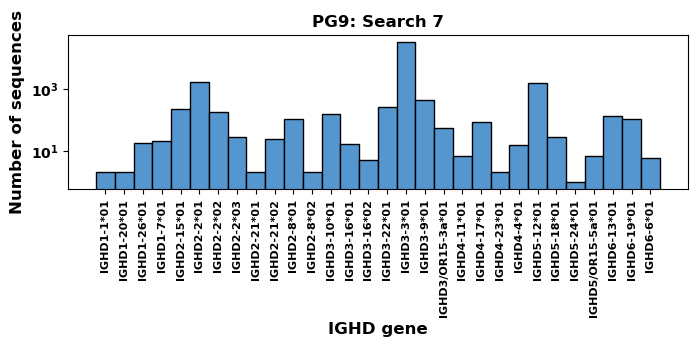

In [51]:
genes = np.concatenate(redundant_seqs_removed_within_donors_dgene_final)# np.load('updated_vgene.npy')
unique_genes = np.unique(genes)

barplot_genes = []
for i in range(len(unique_genes)):
    barplot_genes.append(list(genes).count(unique_genes[i]))

plt.figure(figsize=[8,2])
plt.bar(np.arange(len(barplot_genes)), barplot_genes, width=1, edgecolor='k', color='#5596ce')
plt.xticks(np.arange(len(barplot_genes)), unique_genes, rotation=90, fontsize=8)
plt.yscale('log')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Number of sequences',weight='bold', fontsize=12)
plt.xlabel('IGHD gene',weight='bold', fontsize=12)
plt.title('PG9: Search 7',weight='bold', fontsize=12)
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_dgene_distribution.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_dgene_distribution.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [29]:
unique_cdrh3_seqs_by_donor, unique_jgenes_by_donor = generate_unique_seqs(cdrh3_seqs_by_donor, jgenes_by_donor, save_path)

redundant_seqs_removed_within_donors_cdrh3_final = []
redundant_seqs_removed_within_donors_jgene_final = []
for donor in range(len(unique_cdrh3_seqs_by_donor)):
    redundant_seqs_removed_within_donors_cdrh3, redundant_seqs_removed_within_donors_jgene = remove_almost_duplicates(unique_cdrh3_seqs_by_donor[donor], unique_jgenes_by_donor[donor], save_path)
    redundant_seqs_removed_within_donors_cdrh3_final.append(redundant_seqs_removed_within_donors_cdrh3)
    redundant_seqs_removed_within_donors_jgene_final.append(redundant_seqs_removed_within_donors_jgene)

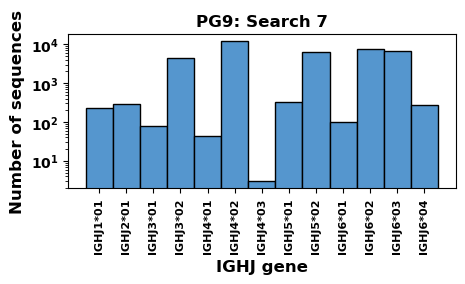

In [50]:
genes = np.concatenate(redundant_seqs_removed_within_donors_jgene_final)# np.load('updated_vgene.npy')
unique_genes = np.unique(genes)

barplot_genes = []
for i in range(len(unique_genes)):
    barplot_genes.append(list(genes).count(unique_genes[i]))


plt.figure(figsize=[5,2])

plt.bar(np.arange(len(barplot_genes)), barplot_genes, width=1, edgecolor='k', color='#5596ce')
plt.xticks(np.arange(len(barplot_genes)), unique_genes, rotation=90, fontsize=8)
plt.yscale('log')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Number of sequences',weight='bold', fontsize=12)
plt.xlabel('IGHJ gene',weight='bold', fontsize=12)
plt.title('PG9: Search 7',weight='bold', fontsize=12)
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_jgene_distribution.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(f'{figure_path}SI_Fig1_PanelC__PG9_nonredundant_jgene_distribution.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()